In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/sudan.csv")
df['Country'] = 'Sudan'
print("Shape:", df.shape)
df.head()

Shape: (4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [3]:
df = df.replace(-999, np.nan)
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [4]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df[['YEAR','DOY','Date']].head()

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [5]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046,3.248907


In [7]:
weather_cols = ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
df[weather_cols] = df[weather_cols].ffill().fillna(df[weather_cols].median())
print("Missing after cleaning:", df.isna().sum().sum())

Missing after cleaning: 0


In [8]:
from scipy import stats
cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z = np.abs(stats.zscore(df[cols].dropna()))
outliers = (z > 3).any(axis=1)
print(f"Rows with |Z|>3: {outliers.sum()}")

Rows with |Z|>3: 84


In [9]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/sudan_clean.csv', index=False)
print("Saved to data/sudan_clean.csv")

Saved to data/sudan_clean.csv


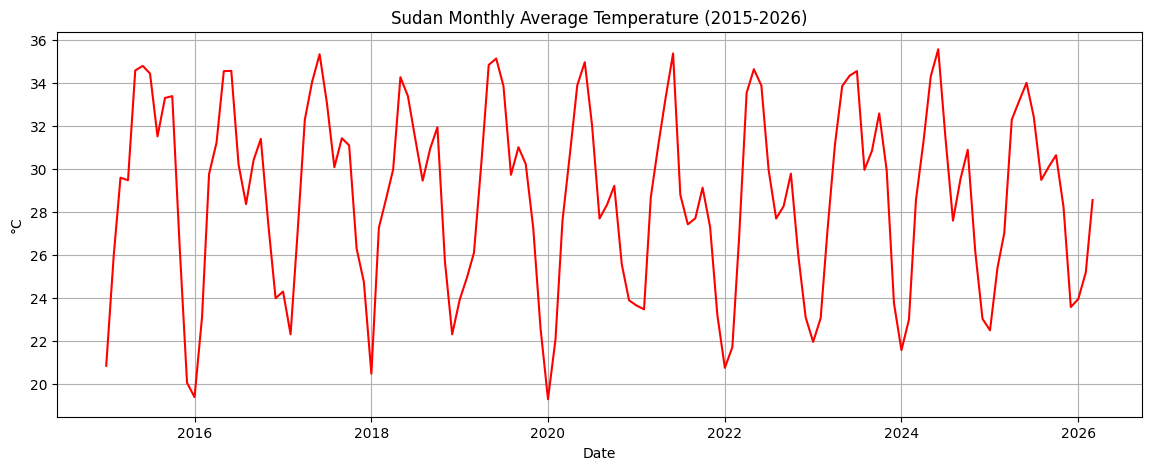

In [10]:
monthly = df.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str))
plt.figure(figsize=(14,5))
plt.plot(monthly['Date'], monthly['T2M'], color='red')
plt.title('Sudan Monthly Average Temperature (2015-2026)')
plt.xlabel('Date'); plt.ylabel('°C')
plt.grid(True)
plt.show()

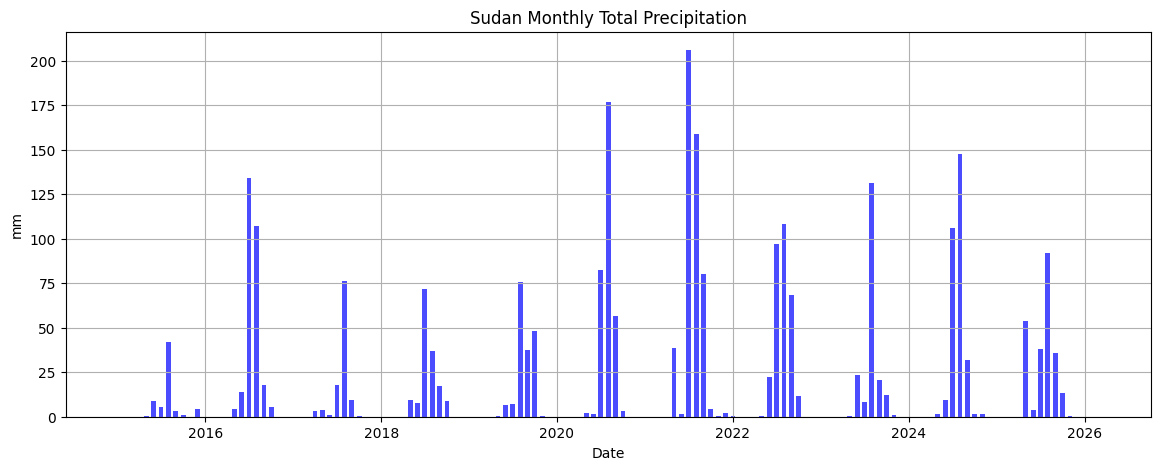

In [11]:
precip = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
precip['Date'] = pd.to_datetime(precip['Year'].astype(str) + '-' + precip['Month'].astype(str))
plt.figure(figsize=(14,5))
plt.bar(precip['Date'], precip['PRECTOTCORR'], width=20, color='blue', alpha=0.7)
plt.title('Sudan Monthly Total Precipitation')
plt.xlabel('Date'); plt.ylabel('mm')
plt.grid(True)
plt.show()

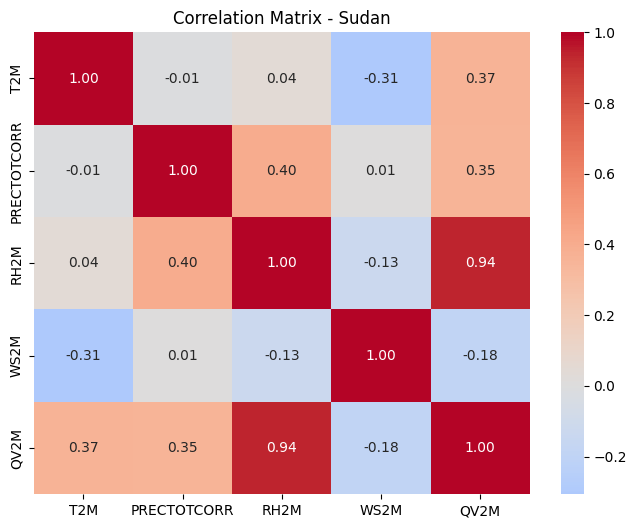

In [12]:
corr = df[['T2M','PRECTOTCORR','RH2M','WS2M','QV2M']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Sudan')
plt.show()

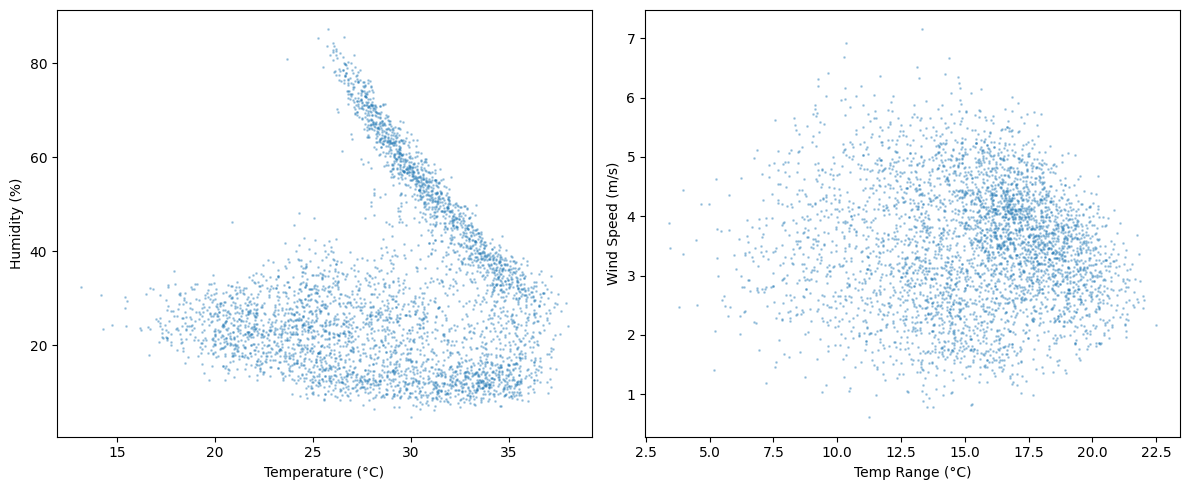

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_ylabel('Humidity (%)')
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
axes[1].set_xlabel('Temp Range (°C)'); axes[1].set_ylabel('Wind Speed (m/s)')
plt.tight_layout()
plt.show()

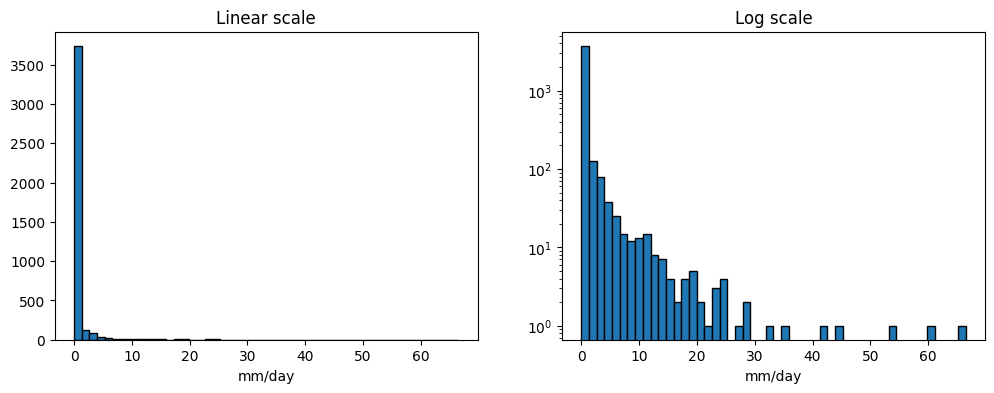

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[0].set_title('Linear scale')
axes[0].set_xlabel('mm/day')
axes[1].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Log scale')
axes[1].set_xlabel('mm/day')
plt.show()

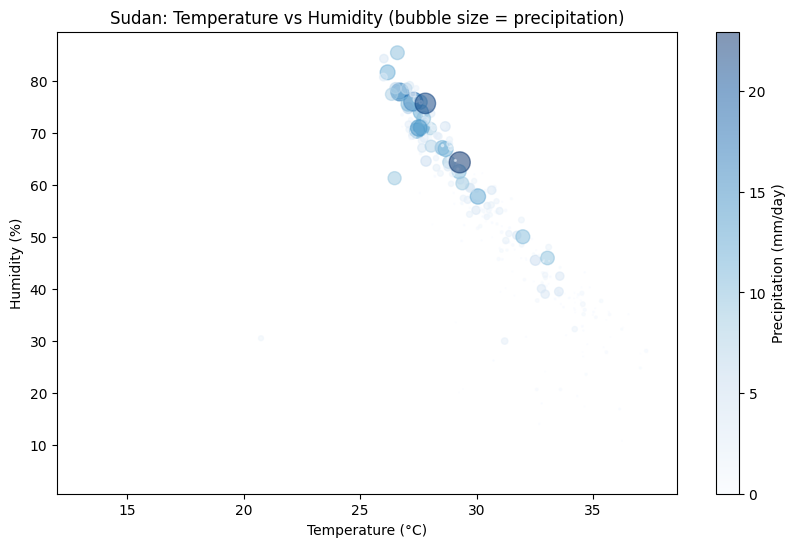

In [15]:
sample = df.sample(min(1000, len(df)))
plt.figure(figsize=(10,6))
sc = plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['PRECTOTCORR'], cmap='Blues')
plt.colorbar(sc, label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)'); plt.ylabel('Humidity (%)')
plt.title('Sudan: Temperature vs Humidity (bubble size = precipitation)')
plt.show()